# AI Model for Heart Disease Prediction

This project builds a machine learning model to predict the likelihood of heart disease using clinical patient data.

The workflow includes:
- Data exploration
- Data preprocessing
- Visualization of key risk factors
- Machine learning model training
- Model evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [3]:
data = pd.read_csv("heart.csv", header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
data.columns = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal","target"]
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [6]:
data = data.replace("?", np.nan)
data = data.apply(pd.to_numeric)
data = data.dropna()

In [7]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
data["target"] = data["target"].apply(lambda x: 1 if x > 0 else 0)

In [9]:
data["target"].value_counts()

target
0    160
1    137
Name: count, dtype: int64

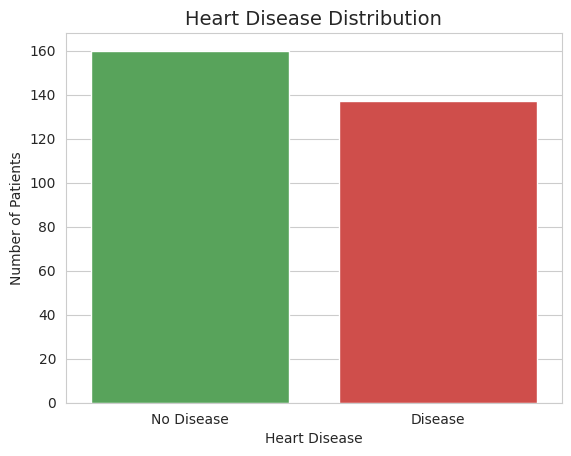

In [10]:
sns.countplot(
    x="target",
    data=data,
    hue="target",
    palette=["#4CAF50", "#E53935"],
    legend=False)

plt.title("Heart Disease Distribution", fontsize=14)
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.xticks([0,1], ["No Disease","Disease"])

plt.savefig("disease_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [11]:
X = data.drop("target", axis=1)
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [13]:
accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.8833333333333333


In [14]:
feature_importance = pd.Series(model.feature_importances_,index=X.columns)

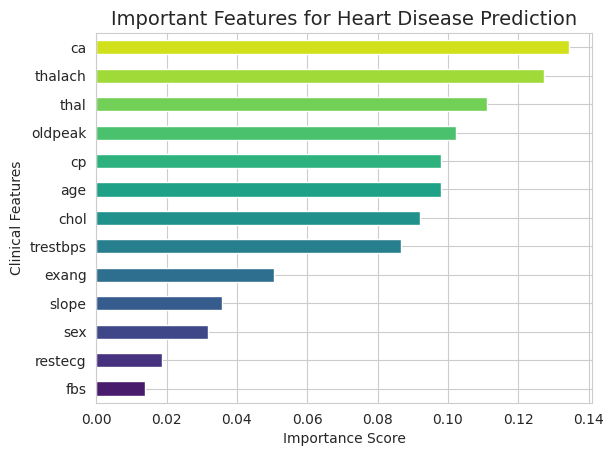

In [15]:
colors = sns.color_palette("viridis", len(feature_importance))

feature_importance.sort_values(ascending=True).plot(
    kind="barh",
    color=colors)

plt.title("Important Features for Heart Disease Prediction", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Clinical Features")

plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

## Model Evaluation – Confusion Matrix

To better understand the model’s performance, we visualize the confusion matrix, which shows how many predictions were correct and where misclassifications occurred.

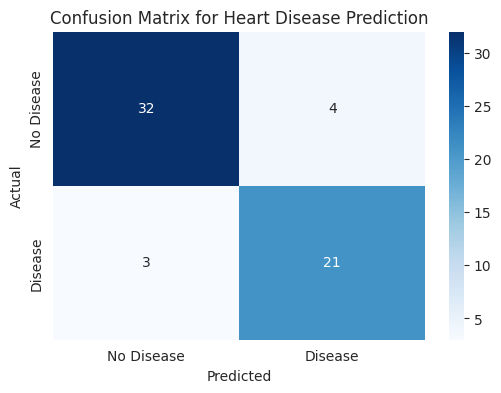

In [16]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease","Disease"],
    yticklabels=["No Disease","Disease"]
)

plt.title("Confusion Matrix for Heart Disease Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

## ROC Curve – Model Performance

To further evaluate the model’s performance, we plot the ROC (Receiver Operating Characteristic) curve. 

The ROC curve illustrates the trade-off between sensitivity (true positive rate) and specificity (false positive rate) across different thresholds. The Area Under the Curve (AUC) provides a measure of how well the model distinguishes between patients with and without heart disease.

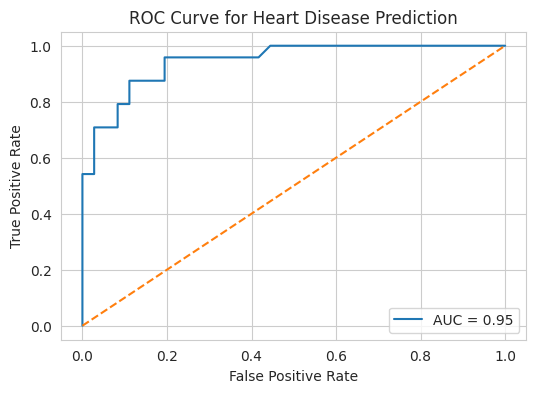

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve for Heart Disease Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")

plt.show()

## Heart Disease Risk Prediction Tool

This simple interface allows users to input clinical patient parameters and obtain a prediction from the trained machine learning model indicating the likelihood of heart disease.

In [20]:
patient_data = {
    "age": 55,
    "sex": 1,
    "cp": 2,
    "trestbps": 130,
    "chol": 250,
    "fbs": 0,
    "restecg": 1,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 1.5,
    "slope": 2,
    "ca": 0,
    "thal": 2}

patient_df = pd.DataFrame([patient_data])

prediction = model.predict(patient_df)

if prediction[0] == 1:
    print("⚠️ Model Prediction: Risk of Heart Disease Detected")
else:
    print("✅ Model Prediction: No Heart Disease Detected")

    probability = model.predict_proba(patient_df)

print("Probability of Heart Disease:", probability[0][1])

✅ Model Prediction: No Heart Disease Detected
Probability of Heart Disease: 0.13


## Conclusion

In this project, a machine learning model was developed to predict the likelihood of heart disease using clinical patient data.

A **Random Forest classifier** was trained on key cardiovascular indicators such as age, cholesterol levels, chest pain type, maximum heart rate achieved, and exercise-induced ST depression. After preprocessing and cleaning the dataset, the model achieved an **accuracy of 88.33%** on the test dataset.

Feature importance analysis identified several key predictors of heart disease risk, including:

- **Number of major vessels (ca)**
- **Maximum heart rate achieved (thalach)**
- **Thalassemia type (thal)**
- **ST depression induced by exercise (oldpeak)**

To better evaluate the model’s performance, additional evaluation metrics such as a **confusion matrix** and **ROC curve** were used to analyze classification behavior and predictive capability.

Finally, a simple **prediction interface** was implemented that allows new patient clinical parameters to be entered and evaluated by the trained model to estimate heart disease risk.

This project demonstrates how machine learning techniques can be applied to healthcare datasets to uncover patterns in cardiovascular risk factors and support early risk identification.